In [ ]:
from transformers import AutoModelForImageClassification, AutoProcessor
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import requests
import matplotlib.pyplot as plt
import random
import numpy as np
import sys
import math

In [ ]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<function matplotlib.pyplot.show(close=None, block=None)>

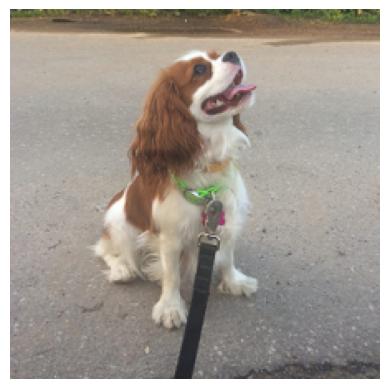

In [ ]:
image = Image.open("/content/sample_data/dog.bmp")

plt.imshow(image)
plt.axis("off")
plt.show

In [ ]:
from transformers import AutoImageProcessor

model_name = "hilmansw/resnet18-catdog-classifier"

model = AutoModelForImageClassification.from_pretrained(model_name).to(device)
model.eval()

# processor = AutoProcessor.from_pretrained(model_name)
# print(processor)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBasicLayer(
              (shortcut): Identity()
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                  (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (activation): ReLU()
           

In [ ]:
# Les Transforms

transformTensor = transforms.ToTensor()

transformPIL = transforms.ToPILImage()

transformIn = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),  # -> je ne suis pas sûr de moi
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalisation -> ImageNet
])

transformOut = transforms.Compose([
    transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
    )
])

In [ ]:
def multiple_copies_generator(image, number_of_copies = 40):
    return image.unsqueeze(0).expand(number_of_copies, -1, -1, -1).to(device) # Format [number_of_copies, 3, x, y]

In [ ]:
import torch

def pixel_to_change_generator(image, lower_pourcentage=0.001, upper_pourcentage=0.01):
    _, height, width = image.shape
    random_pourcentage = torch.FloatTensor(1).uniform_(lower_pourcentage, upper_pourcentage).to(device)
    pixel_to_change = (random_pourcentage * (height * width)).floor().int().item()

    return pixel_to_change#, random_pourcentage.item()

In [ ]:
# Genere aleatoirement les valeurs a ajouter sur chaque pixel

def which_pixel_generator(multiple_copies, pixel_to_change, reach = 1, targeted = False, targeted_channel = 0): # reach = 0.1  ->  -0.1 <= x <= 0.1
                                                                                       # RGB -> 0-R; 1-G; 2-B

    batch_size, channels, height, width = multiple_copies.shape

    # Set the location for the pixels to change and for each dimensions -> in64 for indexing
    pixel_c = torch.full((batch_size, pixel_to_change), targeted_channel, dtype=torch.int64).to(device) if targeted else torch.randint(0, channels, (batch_size, pixel_to_change), dtype=torch.int64).to(device)
    pixel_x = torch.randint(0, height, (batch_size, pixel_to_change), dtype=torch.int64).to(device)
    pixel_y = torch.randint(0, width, (batch_size, pixel_to_change), dtype=torch.int64).to(device)

    # Create a tensor with the values to add (+ and -)
    values_to_change = torch.empty(batch_size, pixel_to_change).uniform_(-reach, reach).to(device)

    multiple_copies = multiple_copies.clone().to(device)  # Remove if modifying original is okay
    multiple_copies[torch.arange(batch_size).unsqueeze(1), pixel_c, pixel_x, pixel_y] += values_to_change

    return multiple_copies.clamp_(0, 1)

In [ ]:
def apply_convolution(tensor, kernel):
    return F.conv2d(tensor.unsqueeze(0).unsqueeze(0), kernel, padding=kernel.shape[2]//2)

In [ ]:
# Rather to modify random pixels
# It mofify pixels next to edges to have a greater impact
# To do that i divide the image into x matrices
# And i use sobel convolution matrices to evaluate the likelyhood to have a sharp edge
# I then take x matrices with the most score and randomly change them

# If elite_matrices = 2; it means 2 matrices changed per orientation (hor, ver) and per channel so 12 modification
# pixel_to_change will be divided into 12 in that case
# So be carefull because changing 100% of the image using only 12 matrices can ads up modifications in the same matrices
# By the way 12 matrices modifications can mean only 6 matrices modified - i need to think about it

def which_pixel_generator_edge(multiple_copies, pixel_to_change, reach = 1, elite_matrices=2, targeted=False, targeted_channel=0): # reach = 0.1  ->  -0.1 <= x <= 0.1

    batch_size, channels, height, width = multiple_copies.shape

    multiple_copies = multiple_copies.clone().to(device)

    image = multiple_copies[0]

    # Convolution matrices
    sobel_horizontal = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    sobel_vertical = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    # we are working with 224x224, we need divider of 224
    divider = 7 # 1, 2, 4, 7, 8, 14, 16, 28, 32, 56, 112, 224
    sub_matrix_size = int(height/divider) # exemple -> 224/7 => 32 7x7 matrices of 32x32 pixels in the 224x224 image

    for c in range(3):

      if targeted:
        c = targeted_channel # Rather than having x matrices changed per channel we have x*3 matrices changed for the targeted channel

      sub_matrices = []
      sub_scores_horizontal = []
      sub_scores_vertical = []

      for h in range(divider): # height iteration
          for w in range(divider): # width iteration

              sub_matrix = image[c, h*sub_matrix_size:(h+1)*sub_matrix_size, w*sub_matrix_size:(w+1)*sub_matrix_size]
              sub_matrices.append(sub_matrix)

              score_horizontal = apply_convolution(sub_matrix, sobel_horizontal).abs().sum().item() # return a matrice of likelihood to have an edge; we then sum up those likelihood to have a score
              score_vertical = apply_convolution(sub_matrix, sobel_vertical).abs().sum().item()

              sub_scores_horizontal.append(score_horizontal)
              sub_scores_vertical.append(score_vertical)

      top_horizontal_indices = torch.topk(torch.tensor(sub_scores_horizontal), elite_matrices).indices # Take the x best score
      top_vertical_indices = torch.topk(torch.tensor(sub_scores_vertical), elite_matrices).indices

      # Divide th total number of pixel to equalize repartition between matrices
      pixel_to_change_sub_matrix = int(pixel_to_change/(elite_matrices*6))

      for index in top_horizontal_indices:
        # Set the location for the pixels to change and for each dimensions -> int64 for indexing

        zone_height = int(index//divider) # Get the height start
        zone_width = int(index%divider) # Get the width start

        # Randomly choose an index for each dimensions
        pixel_c = torch.full((batch_size, pixel_to_change_sub_matrix), c, dtype=torch.int64).to(device)
        pixel_y = torch.randint(zone_height * sub_matrix_size, (zone_height + 1) * sub_matrix_size, (batch_size, pixel_to_change_sub_matrix), dtype=torch.int64).to(device)
        pixel_x = torch.randint(zone_width * sub_matrix_size, (zone_width + 1) * sub_matrix_size, (batch_size, pixel_to_change_sub_matrix), dtype=torch.int64).to(device)

        # Create a tensor with the values to add (+ and -)
        values_to_change = torch.empty(batch_size, pixel_to_change_sub_matrix).uniform_(-reach, reach).to(device)

        multiple_copies[torch.arange(batch_size).unsqueeze(1), pixel_c, pixel_x, pixel_y] += values_to_change

      for index in top_vertical_indices:
        # Set the location for the pixels to change and for each dimensions -> int64 for indexing

        zone_height = int(index//divider) # Get the height start
        zone_width = int(index%divider) # Get the width start

        # Randomly choose an index for each dimensions
        pixel_c = torch.full((batch_size, pixel_to_change_sub_matrix), c, dtype=torch.int64).to(device)
        pixel_y = torch.randint(zone_height * sub_matrix_size, (zone_height + 1) * sub_matrix_size, (batch_size, pixel_to_change_sub_matrix), dtype=torch.int64).to(device)
        pixel_x = torch.randint(zone_width * sub_matrix_size, (zone_width + 1) * sub_matrix_size, (batch_size, pixel_to_change_sub_matrix), dtype=torch.int64).to(device)

        # Create a tensor with the values to add (+ and -)
        values_to_change = torch.empty(batch_size, pixel_to_change_sub_matrix).uniform_(-reach, reach).to(device)

        multiple_copies[torch.arange(batch_size).unsqueeze(1), pixel_c, pixel_x, pixel_y] += values_to_change

    return multiple_copies.clamp_(0, 1)

In [ ]:
# Genere aleatoirement les valeurs a ajouter sur chaque pixel

def which_pixel_generator_noise(multiple_copies, pixel_to_change, reach = 1, targeted = False, targeted_channel = 0): # reach = 0.1  ->  -0.1 <= x <= 0.1
                                                                                       # RGB -> 0-R; 1-G; 2-B

    batch_size, channels, height, width = multiple_copies.shape

    # Set the location for the pixels to change and for each dimensions -> in64 for indexing
    pixel_c = torch.full((batch_size, pixel_to_change), targeted_channel, dtype=torch.int64).to(device) if targeted else torch.randint(0, channels, (batch_size, pixel_to_change), dtype=torch.int64).to(device)
    pixel_x = torch.randint(0, height, (batch_size, pixel_to_change), dtype=torch.int64).to(device)
    pixel_y = torch.randint(0, width, (batch_size, pixel_to_change), dtype=torch.int64).to(device)

    # Create a tensor with the values to add (+ and -)
    values_to_change = torch.empty(batch_size, pixel_to_change).uniform_(0, reach).to(device) # reach is excluded 0.9999...

    multiple_copies = multiple_copies.clone().to(device)  # Remove if modifying original is okay
    multiple_copies[torch.arange(batch_size).unsqueeze(1), pixel_c, pixel_x, pixel_y] += values_to_change

    return multiple_copies.clamp_(0, 1)

In [ ]:
def parent_generator(multiple_copies):
    batch_size = multiple_copies.shape[0]
    number_of_parents = torch.randint(0, batch_size // 2 + 1, (1,)).item() * 2 # Random between 0 and 40 -> even
                                    # Start from 1 to avoid iterations without crossover

    parents_index = torch.randperm(batch_size, device=device)[:number_of_parents]  # shuffle the indexes and take number_of_parents indexes

    return parents_index

In [ ]:
def parent_generator_fixed(multiple_copies):
    batch_size = multiple_copies.shape[0]
    parents_index = torch.randperm(batch_size, device=device) # shuffle the indexes

    return parents_index

In [ ]:
def crossover_generator(multiple_copies, parents_index, pourcentage_height = 0.15):
  multiple_copies_cross = multiple_copies.clone().to(device)

  batch_size, channels, height, width = multiple_copies.shape

  for i in range(0, len(parents_index), 2):
    parent_index_1 = parents_index[i]
    parent_index_2 = parents_index[i + 1]

    max_size_square = int(multiple_copies.shape[3] * pourcentage_height)  # % hauteur de l'image -> multiple_copies[0].shape[2] prend le nombre de pixel d'une image

    # Swaping zone setting
    which_channel = torch.randint(0, channels, (1,)).to(device)
    size_height = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_height = torch.randint(0, height - size_height + 1, (1,)).to(device)
    size_width = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_width = torch.randint(0, width - size_width + 1, (1,)).to(device)

    # Swaping
    swap_zone = multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width,].clone()

    multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = \
        multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width]

    multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = swap_zone

  return multiple_copies_cross

In [ ]:
def through_model(multiple_copies):
    # multiple_copies.shape -> (40, 3, 225, 224)
    batch_size = multiple_copies.shape[0]

    # One pic after the other, transformer don't handle 4D
    input_copies = torch.stack([transformIn(multiple_copies[i]).to(device) for i in range(batch_size)])

    with torch.no_grad():  # CNN inputs
        outputs = model(input_copies)

    processed_copies = transformOut(input_copies)

    logits = outputs.logits  # logits -> [40, num_classes]
    probabilities = torch.nn.functional.softmax(logits, dim=-1)

    return probabilities


In [ ]:
def selection(multiple_copies, probabilities, elites, wanted_class, unwanted_class, wanted=True):

    batch_size, channels, height, width = multiple_copies.shape

    probabilities_class = probabilities[:, wanted_class] if wanted else probabilities[:, unwanted_class]
    probabilities_class = probabilities_class.to(device)

    sorted_probabilities, indices = torch.sort(probabilities_class, descending=wanted)
    sorted_probabilities = sorted_probabilities.to(device)
    indices = indices.to(device)

    elites_index = indices[:elites]
    middle_index = indices[elites:batch_size//2]
    low_index = indices[batch_size//2:]

    elites_proba = sorted_probabilities[:elites]
    middle_proba = sorted_probabilities[elites:batch_size//2]
    low_proba = sorted_probabilities[batch_size//2:]

    elites_proba = elites_proba.float()
    middle_proba = middle_proba.float()
    low_proba = low_proba.float()

    elites_selection = multiple_copies[elites_index].to(device)
    middle_selection = multiple_copies[middle_index].to(device)
    low_selection = multiple_copies[low_index].to(device)

    #return elites_selection, middle_selection, low_selection, elites_index, elites_proba
    return elites_selection, middle_selection, elites_index, elites_proba

In [ ]:
def from_rgb_to_ycbcr(tensor_image):
    transform_matrix = torch.tensor([[0.299, 0.587, 0.114],
                                     [-0.169, -0.331, 0.499],
                                     [0.499, -0.460, -0.039]], device=device)

    tensor_image_ycbcr = torch.matmul(transform_matrix, tensor_image.view(3, -1)).to(device)

    # Reshape to have the original pytorch shape for images
    tensor_image_ycbcr = tensor_image_ycbcr.view(3, tensor_image.shape[1], tensor_image.shape[2])

    return tensor_image_ycbcr

In [ ]:
def checker(elites_index, elites_proba, threshold):

    # Search uniquely in elites
    for i in range(len(elites_proba)):
      if elites_proba[i] >= threshold:
        return True, elites_index[i]
      else:
        return False, -1

50176


model.safetensors:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

29271
torch.Size([40, 3, 224, 224])


<function matplotlib.pyplot.show(close=None, block=None)>

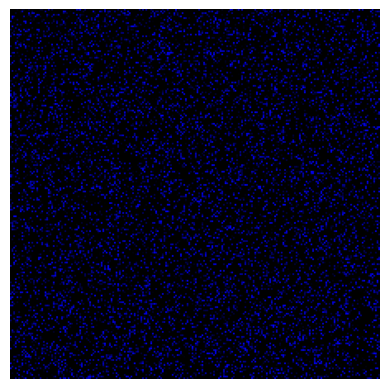

In [ ]:
# Test Noise only

tensor_image = torch.zeros(3, 224, 224)
print(tensor_image.shape[1]*tensor_image.shape[2])
pixel_to_change = pixel_to_change_generator(tensor_image,upper_pourcentage=1)
print(pixel_to_change)
group_tensor_image = multiple_copies_generator(tensor_image, 40)
print(group_tensor_image.shape)

group_tensor_image = which_pixel_generator(group_tensor_image, pixel_to_change, reach=1, targeted=True, targeted_channel=2)

test_image = group_tensor_image[0]

image_restored = transformPIL(test_image)
plt.imshow(image_restored)
plt.axis("off")
plt.show

50176
12894
torch.Size([40, 3, 224, 224])


<function matplotlib.pyplot.show(close=None, block=None)>

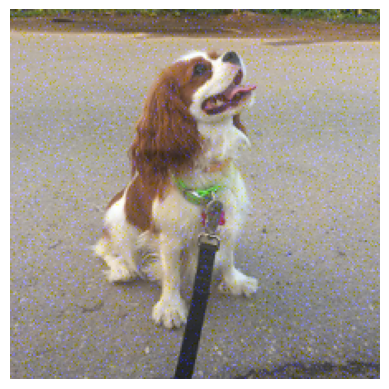

In [ ]:
# Test which_pixel_generator()
image = Image.open("/content/sample_data/dog.bmp")

tensor_image = transformTensor(image).to(device)
print(tensor_image.shape[1]*tensor_image.shape[2])
pixel_to_change = pixel_to_change_generator(tensor_image,upper_pourcentage=0.5)
print(pixel_to_change)
group_tensor_image = multiple_copies_generator(tensor_image, 40)
print(group_tensor_image.shape)

group_tensor_image = which_pixel_generator(group_tensor_image, pixel_to_change, reach=0.5, targeted=True, targeted_channel=2)

test_image = group_tensor_image[0]

image_restored = transformPIL(test_image)
plt.imshow(image_restored)
plt.axis("off")
plt.show

50176
8757
torch.Size([40, 3, 224, 224])


<function matplotlib.pyplot.show(close=None, block=None)>

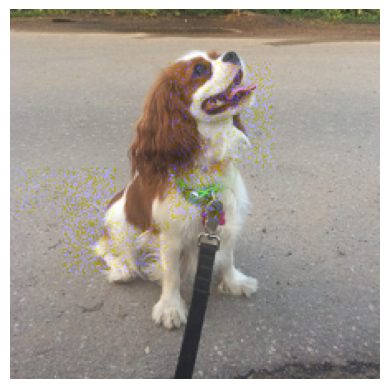

In [ ]:
# Test which_pixel_generator_edge()

image = Image.open("/content/sample_data/dog.bmp")

tensor_image = transformTensor(image).to(device)
print(tensor_image.shape[1]*tensor_image.shape[2])
pixel_to_change = pixel_to_change_generator(tensor_image,upper_pourcentage=0.5)
print(pixel_to_change)
group_tensor_image = multiple_copies_generator(tensor_image, 40)
print(group_tensor_image.shape)

group_tensor_image = which_pixel_generator_edge(group_tensor_image, pixel_to_change, reach=0.5, elite_matrices=4, targeted=True, targeted_channel=2)
test_image = group_tensor_image[0]

image_restored = transformPIL(test_image)
plt.imshow(image_restored)
plt.axis("off")
plt.show

In [ ]:
# NORMAL VERSION
# WITH ADDITIONAL NOISE -> ADS UP
# ⚙️ HYPERPARAMETERS

# Free GPU cache
torch.cuda.empty_cache()

ENUMS = 500

WANTED_CLASS = 0
UNWANTED_CLASS = 1 # not used

HEIGHT = 0.15 # significantly increse running time; its the height of the crossover square

REACH = 0.5 # value added to each pixel -> -REACH <= x <= REACH
REACH_NOISE = 0.01 # to add really small mutations

MAX_POURCENTAGE = 0.05 # maximum number of pixels changed = MAX_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MIN_POURCENTAGE = 0.0 # minimum number of pixels changed = MIN_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MAX_POURCENTAGE_NOISE = 0.05

ELITES = 10
ELITES_MATRICES = 4
ELITES_MATRICES_NOISE = 4

TARGETED = True
TARGETED_CHANNEL = 2

THRESHOLD = 0.6 # sucess if the image is considered (THRESHOLD*10)% of the wanted class -> 0.6 = 60% of the wanted class

# 🧑‍🎨 LOAD AND PROCESS THE BASE IMAGE
image = Image.open("/content/sample_data/dog.bmp")

tensor_image = transformTensor(image).to(device)
multiple_copies = multiple_copies_generator(tensor_image, 40)

pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE)

multiple_copies = which_pixel_generator(multiple_copies, pixel_to_change, reach=REACH, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

# 🤖 MODEL AND SELECTION
probabilities = through_model(multiple_copies)
elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

predicted_classes = torch.argmax(probabilities, dim=-1) # return the classes that the model predicted for each image
print(predicted_classes) # Just for the visual

for i in range(ENUMS):
  print(i)

  # 👨‍💻 COMPUTE EACH SPLIT (20-20) => 40

  top_selection = torch.cat((elites_selection, middle_selection)).clone() # no need for clone here i might remove it after checking

  # 20 -> add noise
  pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE_NOISE)
  noise_selection = which_pixel_generator(top_selection, pixel_to_change, reach=REACH_NOISE, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL) # must be really small -> it adds up with the iterations

  # 20 -> crossover
  parents_index = parent_generator_fixed(top_selection)
  crossed_copies = crossover_generator(top_selection, parents_index, pourcentage_height=HEIGHT)

  # 20 + 20 = 40 index
  multiple_copies = torch.cat((crossed_copies, noise_selection)) # concatenate the splits together

  # ❗️Now we have the final image set for this iteration to pass through the model!

  # 🤖 MODEL AND SELECTION
  probabilities = through_model(multiple_copies)

  probabilities_wanted = probabilities[:, WANTED_CLASS]
  print(probabilities_wanted)
  print(probabilities_wanted.sum().item())

  elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

  # 👍 RESULTS FOUND?/ HOW GOOD ARE THEY?
  success, success_index = checker(elites_index, elites_proba, THRESHOLD)
  if success:
    print("Adversarial image found!")
    adv_image = multiple_copies[success_index]

    # 🥸 DISPLAY BEST IMAGE
    image_restored = transformPIL(adv_image)
    plt.imshow(image_restored)
    plt.axis("off")
    plt.show

    break

In [ ]:
# EDGE VERSION

# WITH ADDITIONAL NOISE -> ADS UP
# ⚙️ HYPERPARAMETERS

# Free GPU cache
torch.cuda.empty_cache()

ENUMS = 500

WANTED_CLASS = 0
UNWANTED_CLASS = 1 # not used

HEIGHT = 0.15 # significantly increse running time; its the height of the crossover square

REACH = 0.5 # value added to each pixel -> -REACH <= x <= REACH
REACH_NOISE = 0.01 # to add really small mutations

MAX_POURCENTAGE = 0.05 # maximum number of pixels changed = MAX_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MIN_POURCENTAGE = 0.0 # minimum number of pixels changed = MIN_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MAX_POURCENTAGE_NOISE = 0.05

ELITES = 10
ELITES_MATRICES = 4
ELITES_MATRICES_NOISE = 4

TARGETED = True
TARGETED_CHANNEL = 2

THRESHOLD = 0.6 # sucess if the image is considered (THRESHOLD*10)% of the wanted class -> 0.6 = 60% of the wanted class

# 🧑‍🎨 LOAD AND PROCESS THE BASE IMAGE
image = Image.open("/content/sample_data/dog.bmp")

tensor_image = transformTensor(image).to(device)
multiple_copies = multiple_copies_generator(tensor_image, 40)

pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE)

multiple_copies = which_pixel_generator_edge(multiple_copies, pixel_to_change, reach=REACH, elite_matrices=ELITES_MATRICES, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

# 🤖 MODEL AND SELECTION
probabilities = through_model(multiple_copies)
elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

predicted_classes = torch.argmax(probabilities, dim=-1) # return the classes that the model predicted for each image
print(predicted_classes) # Just for the visual

for i in range(ENUMS):
  print(i)

  # 👨‍💻 COMPUTE EACH SPLIT (20-20) => 40

  top_selection = torch.cat((elites_selection, middle_selection)).clone() # no need for clone here i might remove it after checking

  # 20 -> add noise
  pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE_NOISE)
  noise_selection = which_pixel_generator_edge(top_selection, pixel_to_change, reach=REACH_NOISE, elite_matrices=ELITES_MATRICES_NOISE, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL) # must be really small -> it adds up with the iterations

  # 20 -> crossover
  parents_index = parent_generator_fixed(top_selection)
  crossed_copies = crossover_generator(top_selection, parents_index, pourcentage_height=HEIGHT)

  # 20 + 20 = 40 index
  multiple_copies = torch.cat((crossed_copies, noise_selection)) # concatenate the splits together

  # ❗️Now we have the final image set for this iteration to pass through the model!

  # 🤖 MODEL AND SELECTION
  probabilities = through_model(multiple_copies)

  probabilities_wanted = probabilities[:, WANTED_CLASS]
  print(probabilities_wanted)
  print(probabilities_wanted.sum().item())

  elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

  # 👍 RESULTS FOUND?/ HOW GOOD ARE THEY?
  success, success_index = checker(elites_index, elites_proba, THRESHOLD)
  if success:
    print("Adversarial image found!")
    adv_image = multiple_copies[success_index]

    # 🥸 DISPLAY BEST IMAGE
    image_restored = transformPIL(adv_image)
    plt.imshow(image_restored)
    plt.axis("off")
    plt.show

    break

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
0
tensor([0.7815, 0.7804, 0.7775, 0.7768, 0.7771, 0.7754, 0.7754, 0.7742, 0.7738,
        0.7714, 0.7681, 0.7690, 0.7683, 0.7673, 0.7666, 0.7667, 0.7669, 0.7668,
        0.7661, 0.7660, 0.7784, 0.7797, 0.7753, 0.7728, 0.7722, 0.7705, 0.7802,
        0.7658, 0.7690, 0.7672, 0.7703, 0.7684, 0.7590, 0.7640, 0.7672, 0.7616,
        0.7676, 0.7596, 0.7703, 0.7656], device='cuda:0')
30.819801330566406
1
tensor([0.7815, 0.7804, 0.7802, 0.7797, 0.7799, 0.7775, 0.7771, 0.7768, 0.7754,
        0.7754, 0.7753, 0.7713, 0.7738, 0.7728, 0.7722, 0.7714, 0.7705, 0.7699,
        0.7703, 0.7694, 0.7733, 0.7683, 0.7670, 0.7626, 0.7690, 0.7740, 0.7733,
        0.7723, 0.7671, 0.7616, 0.7814, 0.7641, 0.7643, 0.7675, 0.7659, 0.7605,
        0.7562, 0.7608, 0.7651, 0.7660], device='cuda:0')
30.84087562561035
2
tensor([0.7801, 0.7787, 0.7804, 0.7802, 0.7799,

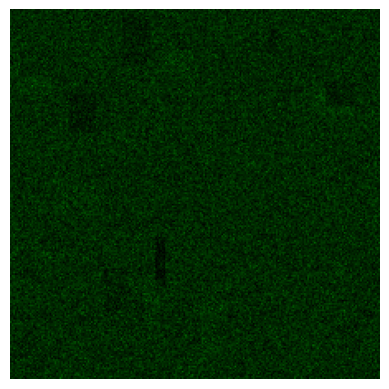

In [ ]:
# NOISE VERSION
# WITH NOISE ONLY, NO IMAGES
# ⚙️ HYPERPARAMETERS

# Free GPU cache
torch.cuda.empty_cache()

ENUMS = 1000

WANTED_CLASS = 0
UNWANTED_CLASS = 1 # not used

HEIGHT = 0.15 # significantly increse running time; its the height of the crossover square

REACH = 0.1 # value added to each pixel -> -REACH <= x <= REACH
REACH_NOISE = 0.05 # to add really small mutations

MAX_POURCENTAGE = 1 # maximum number of pixels changed = MAX_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MIN_POURCENTAGE = 0.0 # minimum number of pixels changed = MIN_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MAX_POURCENTAGE_NOISE = 1

ELITES = 10

TARGETED = True
TARGETED_CHANNEL = 1

THRESHOLD = 0.98 # sucess if the image is considered (THRESHOLD*10)% of the wanted class -> 0.6 = 60% of the wanted class

# 🧑‍🎨 LOAD AND PROCESS THE BASE IMAGE

tensor_image = torch.zeros(3, 224, 224)
multiple_copies = multiple_copies_generator(tensor_image, 40)

pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE)

multiple_copies = which_pixel_generator_noise(multiple_copies, pixel_to_change, reach=REACH, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

# 🤖 MODEL AND SELECTION
probabilities = through_model(multiple_copies)
elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

predicted_classes = torch.argmax(probabilities, dim=-1) # return the classes that the model predicted for each image
print(predicted_classes) # Just for the visual

for i in range(ENUMS):
  print(i)

  # 👨‍💻 COMPUTE EACH SPLIT (20-20) => 40

  top_selection = torch.cat((elites_selection, middle_selection)).clone() # no need for clone here i might remove it after checking

  # 20 -> add noise
  pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE_NOISE)
  noise_selection = which_pixel_generator_noise(top_selection, pixel_to_change, reach=REACH_NOISE, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL) # must be really small -> it adds up with the iterations

  # 20 -> crossover
  parents_index = parent_generator_fixed(top_selection)
  crossed_copies = crossover_generator(top_selection, parents_index, pourcentage_height=HEIGHT)

  # 20 + 20 = 40 index
  multiple_copies = torch.cat((crossed_copies, noise_selection)) # concatenate the splits together

  # ❗️Now we have the final image set for this iteration to pass through the model!

  # 🤖 MODEL AND SELECTION
  probabilities = through_model(multiple_copies)

  probabilities_wanted = probabilities[:, WANTED_CLASS]
  print(probabilities_wanted)
  print(probabilities_wanted.sum().item())

  elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

  # 👍 RESULTS FOUND?/ HOW GOOD ARE THEY?
  success, success_index = checker(elites_index, elites_proba, THRESHOLD)
  if success:
    print("Adversarial image found!")
    adv_image = multiple_copies[success_index]

    # 🥸 DISPLAY BEST IMAGE
    image_restored = transformPIL(adv_image)
    plt.imshow(image_restored)
    plt.axis("off")
    plt.show

    break